# **Frozen Lake com aprendizado de política**

In [10]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

## **Treinando agente por Q-Learning**

In [11]:
def run(episodes, render=False):
    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human' if render else None)

    q = np.zeros((env.observation_space.n, env.action_space.n)) # inicializando um array 64x4 só com zeros

    rewards_per_episode = np.zeros(episodes)


    '''hiperparâmetros'''
    learning_rate_a = 0.7           # alpha ou learning rate
    discount_factor_g = 0.95         # gamma ou discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state
    epsilon = 1                     # 1 = 100% random actions
    epsilon_decay_rate = 0.0001     # epsilon decay rate. 1/0.0001 = 10000 episodes mín no treinamento
    rng = np.random.default_rng()   # random number generator


    for i in range(episodes):
        obs = env.reset()    # env.reset() retorna (obs, info) e queremos apenas a primeira
        obs = obs[0]         # obs: 0 a 63, sendo 0=top left e 63=bottom right
        terminated = False      # True quando cai no buraco ou quando chega na recompensa
        truncated = False       # True quando actions > 200


        while(not terminated and not truncated):
            '''
            se o número aleatório gerado for menor que epsilon, a ação tomada é aleatória,
            caso contrário, seguirá a Q-Table
            '''
            if rng.random() < epsilon:
                action = env.action_space.sample() # actions: 0=left,1=down,2=right,3=up
            else:
                # vai na linha do estado atual e vê qual é a ação com maior valor
                action = np.argmax(q[obs,:])       # seleciona a posição da tabela com maior pontuação

            new_obs, reward, terminated, truncated, _ = env.step(action)


            '''fórmula para calcular os elementos da Q-Table'''
            q[obs,action] = q[obs,action] + learning_rate_a * (
                        reward + discount_factor_g * np.max(q[new_obs,:]) - q[obs,action])
            
            obs = new_obs


        '''depois de cada episódio, reduzimos o epsilon até que ele seja zero (em algum momento)'''
        epsilon = max(epsilon - epsilon_decay_rate, 0)

        
        if(epsilon==0): # ajuda a estabilizar os q-values
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()


    '''plotar o gráfico de recompensas(episódios)'''
    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.xlabel("Episodes")
    plt.ylabel("Episode Rewards")
    plt.savefig('frozen_lake8x8.png')


    '''salvando a q-table em arquivo para poder usá-la após o treinamento'''
    f = open("frozen_lake8x8.pkl","wb")
    pickle.dump(q, f)
    f.close()

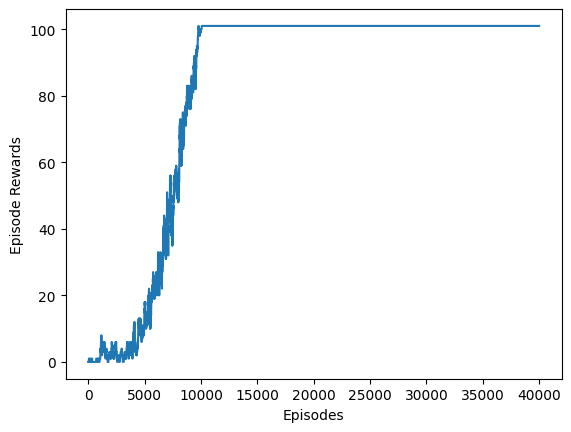

In [16]:
if __name__ == '__main__':
    run(40000)

In [13]:
def run_training(episodes, is_training=True, render=False):

    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human' if render else None)

    if(is_training):
        q = np.zeros((env.observation_space.n, env.action_space.n)) # init a 64 x 4 array
    else:
        f = open('frozen_lake8x8.pkl', 'rb')
        q = pickle.load(f)
        f.close()

    learning_rate_a = 0.9           # alpha or learning rate
    discount_factor_g = 0.9         # gamma or discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state.
    epsilon = 1                     # 1 = 100% random actions
    epsilon_decay_rate = 0.0001     # epsilon decay rate. 1/0.0001 = 10,000
    rng = np.random.default_rng()   # random number generator

    rewards_per_episode = np.zeros(episodes)

    for i in range(episodes):
        state = env.reset()[0]  # states: 0 to 63, 0=top left corner,63=bottom right corner
        terminated = False      # True when fall in hole or reached goal
        truncated = False       # True when actions > 200

        while(not terminated and not truncated):
            if is_training and rng.random() < epsilon:
                action = env.action_space.sample() # actions: 0=left,1=down,2=right,3=up
            else:
                action = np.argmax(q[state,:])

            new_state,reward,terminated,truncated,_ = env.step(action)

            if is_training:
                q[state,action] = q[state,action] + learning_rate_a * (
                    reward + discount_factor_g * np.max(q[new_state,:]) - q[state,action]
                )

            state = new_state

        epsilon = max(epsilon - epsilon_decay_rate, 0)

        if(epsilon==0):
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()

    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.savefig('frozen_lake8x8.png')

    if is_training:
        f = open("frozen_lake8x8.pkl","wb")
        pickle.dump(q, f)
        f.close()

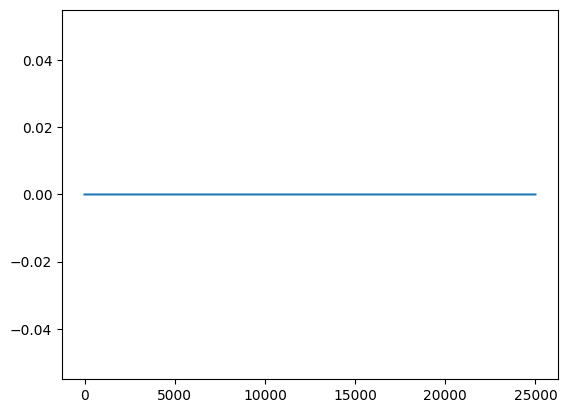

In [14]:
if __name__ == '__main__':
    # run(15000)

    run_training(25000, is_training=True, render=False)
    #run(1, is_training=False, render=True)